In [29]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [30]:
image_path = '/content/drive/MyDrive/rokey/AI/application/3/copy.png'

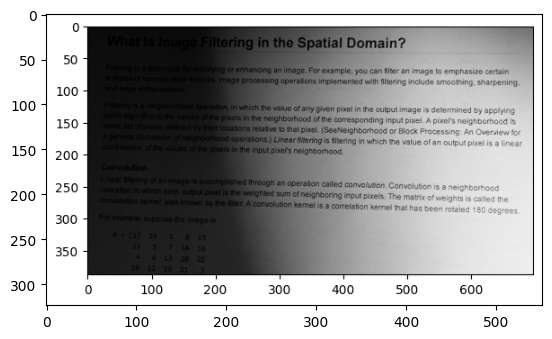

In [31]:
image = cv2.imread(image_path)
plt.imshow(image)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
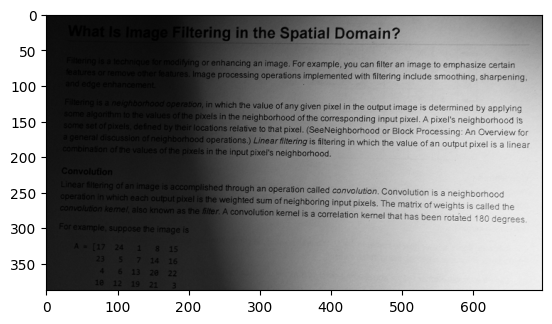

In [ ]:
# 이진화: 흑백(0,255(1)) 채널로 이미지 변경
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

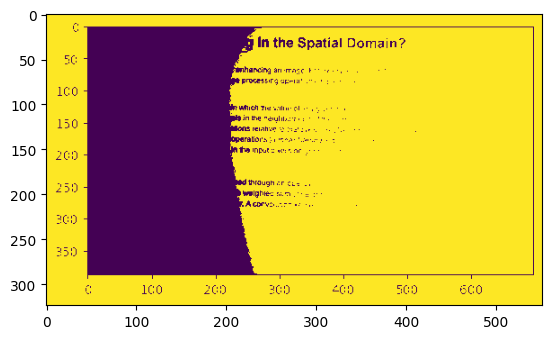

In [32]:
# 임계값(threshold)
result, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
# 50 : 임계값 (50보다 어두우면 검정, 밝으면 흰색(255))
plt.imshow(binary)

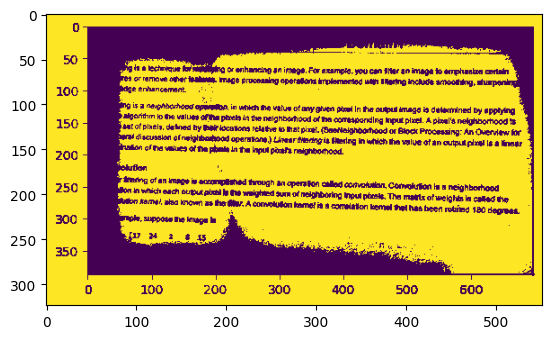

In [33]:
# 적응형 이진화
# >> 영역마다 다른 임계값 사용하겠다는 의미 (cf. 일반적으로 이진화라 같은 기준)
binary_ad = cv2.adaptiveThreshold(
                gray,                       # 적용할 이미지
                255,                        # 최대값(255를 넘는 건 없다)
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C, # 옵션(적응형의 판단기준) 주변 픽셀의 가중평균(가우시안)
                cv2.THRESH_BINARY,          # 조건(threshold 임계치)에 맞으면 결과를 이렇게 해줘(흰검)
                121,                        # 121: 커널 크기(정확히는 블록 크기, 주변 영역의 크기)
                4                           # 상수 (평균/가중평균에서 빼는 값)
            )

# 단계
# (121*121) 커널 가져와요. 주변 픽셀 값 가져와요.
# (옵션) cv2.ADAPTIVE_THRESH_GAUSSIAN_C 활용, 주변 픽셀에 가우시안 평균(가중평균) 적용
# 가중평균할때 계산되는 가중치 값을 가우시안 분포를 바탕으로 계산해서 가중치를 적용해, 평균값을 구하는 것
# 여기서 나온 평균값에서 상수 (4)를 뺀 값을 threshold T로 사용
# 픽셀값이 T 보다 크면 >> 흰색(255), 작으면 검정색(0) : THRESH_BINARY
# 상수 빼기 : "너무 밝게 나오지 않게 살짝 빼주세요"하고 평균 밝기에서 4를 빼주는 역할
# C 상수의 값이 크면 >> Threshold 낮아짐 >> 더 밝게 잡힘
# 어디에 사용하나요? 로봇 라인트레이싱, OCR, 자동차 번호판 인식 (조명 변화에 강해요)

plt.imshow(binary_ad)

In [34]:
cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

(127.0,
 array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], dtype=uint8))

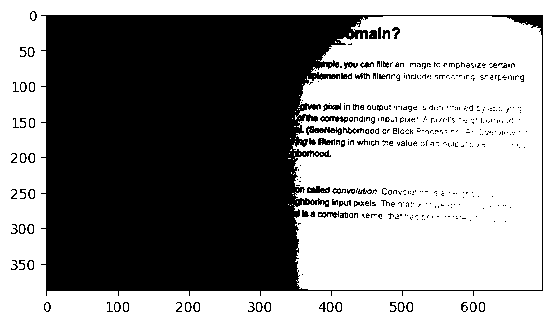

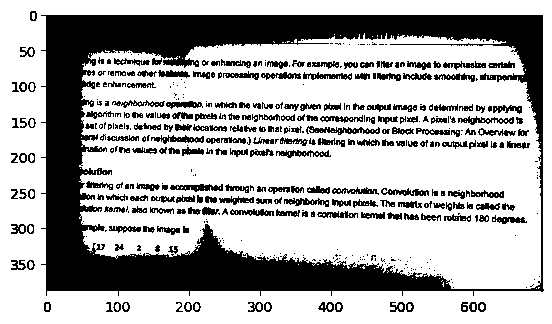

In [35]:
result, binary_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
binary_ad = cv2.adaptiveThreshold(gray, 255,
                                  cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 121, 4)
cv2_imshow(binary_global) # 검은 부분 생기거나 깨짐
cv2_imshow(binary_ad) # 글자/라인 선명하게 추출

# binary_ad
# 어디까지 전처리한거야?
# 1) 이미지 불러와서 이진화(흑백)
# 2) 적응형 임계값threshold 처리

엣지 검출

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
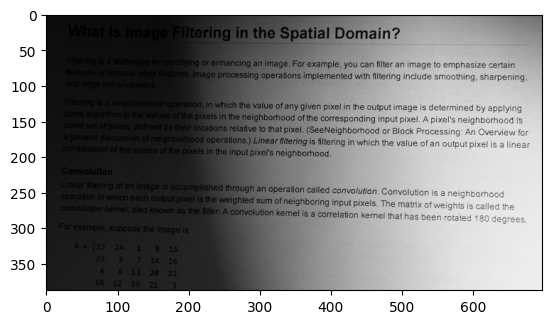

In [36]:
# 소벨 필터(sobel filter)
# 1차 미분, Slope(gradient)
# 영상의 밝기 변화량(gradient) >> 물체 윤곽선(contour), 경계(edge) 추출
# 밝기가 급격하게 변하네 >> edge(경계)네, 변화 없네 >> 배경이네
# >> 경계의 방향과 강도 계산

image  = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
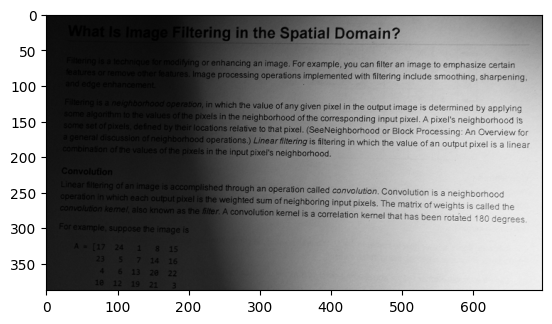

In [37]:
gray

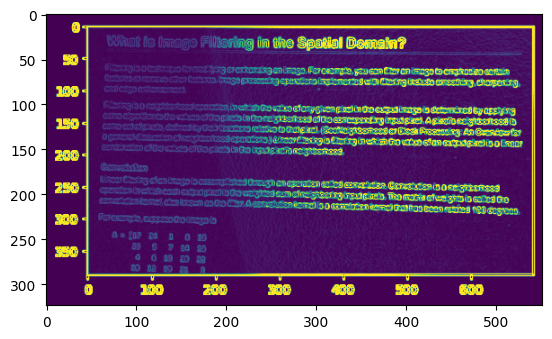

In [38]:
# 소벨 필터 적용
# 1, 0 >> 수평 엣지, / 0, 1 >> 수직 엣지
# ksize : 커널 사이즈

gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

# binary_ad : 적응형 이진화를 거친 이미지를 가지고 와서
# gx : x방향 (가로) 변화 감지 >> 세로선 찾기
#   >> dx = 1: x축 방향으로 미분
#   >> dy = 0: y축 방향으로 미분 안함
# gy : y방향 (세로) 변화 감지 >> 가로선 찾기
#   >> dx = 0: x축 방향으로 미분 안함
#   >> dy = 1: y축 방향으로 미분
# cv2.CV_32F : 32비트 실수형(실수라는 음수도 포함하잖아 >> 정밀하게 계산할거야), 입력 정밀도에 따른 오버플로우 방지를 위해
# cf. uint8 (일반 이미지) openCV나 matplotlib 일반 이미지로 인식(0-255)
# ksize = 3 (3*3 필터 쓸게)

plt.imshow(gx)

# 필터를 사용하여 엣지의 강도 추출
mag = cv2.magnitude(gx, gy)
# 피타고라스 정리 활용 >> 전체 엣지 강도 계산, mag = sqrt(gx^2 + gy^2)
# gx(x방향 기울기, 밝기 변화량), gy(y방향 기울기, 밝기 변화량)
# 경계의 방향은 상관없어요. 얼마나 강한 edge인지 계산함
# print(mag)  # 계산한 변화량 출력
# mag 부분을 이미지로 표현하도록 0-255 사이로 표현하도록 강제
mag = np.uint8(np.clip(mag, 0, 255))
# mag(강도)를 0과 255 사이로 강제해서 openCV가 이해하도록 unsinged integer 8bit로 변환
# if) mag=-50이면 mag=0, mag=500이면 mag=255로 강제됨
plt.imshow(mag)

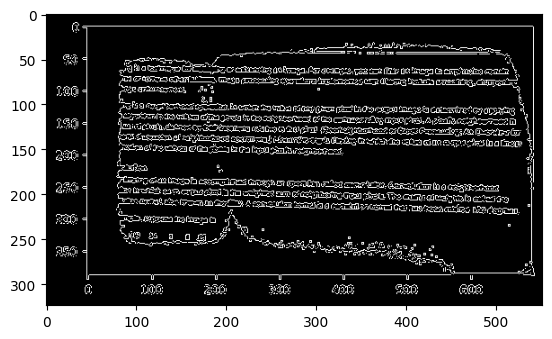

In [41]:
# Canny 필터 (적용할 이미지, 낮은 임계값, 높은 임계값)

result = cv2.Canny(binary_ad, 100, 200)
# binary_ad : 노이즈 제거, 그래디언트 계산, 비최대 억제까지 거친 이미지(안해도 알아서 Canny 함수가 해줌)
# 30: 낮은 임계값 (약한 엣지)
# 200: 높은 임계값 (강한 엣지)
# 30-200 사이에 있는 값(강한 엣지와 연결되면 살림)
plt.imshow(result, cmap='gray')

Canny Filter 동작방식(Canny 내장된 기능)
1. 노이즈 제거(Gaussian Blur)
2. 그래디언트 계산(Sobel Filter)
3. 비최대 억제(Non-Maximum Suppression) : 엣지의 방향을 따라 로컬의 최댓값만 남기고 나머지는 억제
4. 이중 임계값 처리(Double Thresholding) : 강한 엣지, 약한 엣지를 파악하여 약한 엣지는 강한 엣지와 연결되었을 때만 보존
5. 강한 엣지와 연결되지 않은 약한 엣지는 제거


In [ ]:
# binary_ad
# 어디까지 전처리한거야?
# 1) 이미지 불러와서 이진화(흑백)
# 2) 적응형 임계값threshold 처리
# 여기까지 전처리한 이미지로 canny 엣지 검출

In [ ]:
# ksize와 blocksize 차이가 뭐예요?
# ksize: 필터, 마스크의 크기 (홀수만 가능 3*3, 5*5, 11*11)
# blocksize: adaptiveThreshold 같이 적응형 기반 계산하기 위함 (주변 영역의 이웃의 크기)
# 즉 평균 구할 영역의 크기(홀수만 가능)
# ksize=3, 3*3: 기울기 계산용 커널(소벨 필터) 사이즈
# blocksize=2, 2*2: 코너 판단용 윈도우 사이즈, 코너 점point 계산할 때 고려하는 주변 영역 크기
# k=0.04 민감도(threshold 임계치) 조절(0.04-0.06) :클수록 더 민감하게 반응 >> 코너가 더 많이 검출

코너(모서리) 검출 알고리즘
- 해리스코너(코너) 알고리즘
- 시-토마스 알고리즘


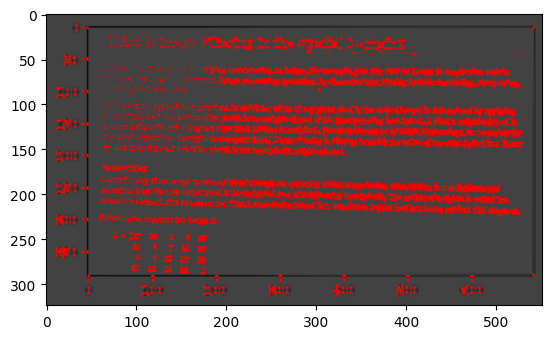

In [46]:
# 해리스 코너 검출기
# 윈도우를 모든 방향으로 움직였을 때, 픽셀 값의 변화가 가장 큰 지점을 코너라고 생각
# 욜로 nms: 박스 하나남기기
# 해리스코너 nms: 코너 하나 남기기

# grayscale로 변환해야 harrys를 쓸 수 있다.
harris = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
# 모서리(corner) 찾기
# 코너랑 두 방향으로 모두 강한 밝기 변화량이 존재하는 곳(특징점=변화량이 급격한 아주 유용한 픽셀 추출)
# 코너(선과 선이 교차하는 곳) 저기가 코너일 가능성이 얼마나 높지?
# >> score가 높을수록 코너일 가능성이 높음 (scoremap)

# np.float32(gray) : gradient 계산(미분) uint8 >> float32 (harris 내부에서 계산할 때는 float32로 해야함)
# blocksize=2: (2*2) 영역씩 검사
# k=0.04 민감도 조절(작을수록 더 많이 검출)

'''
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
'''

harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# 결과를 0-255 범위 정규화(unit8)
# harris : 해리스 코너 검출 결과값 >> 0-255 사이로 정규화normalize
# openCV에 맞춰서 unsigned integer로 변환
# >> 코너의 강도 값을 사람이 보기 쉽게 이미지 형태로 변환해줘
# None = 저장할 배열 없음 → 출력 이미지를 새로 만들라는 뜻
# minmax에서 min=0, max=255
# 왜 정규화 주나요?
# 해리스 검출 결과가 점수(score) 맵(map) 이기 때문(값 범위가 매우 크거나 음수일 수 있다)
# harris_norm = (harris - min(harris)) / (max(harris) - min(harris)) * 255

corner = cv2.cvtColor(harris_norm, cv2.COLOR_BGR2RGB)
# print(corner)

corner[harris > 0.9*harris_norm.max()] = [255, 0, 0]
# 상위 10% 강한 코너만 빨간색(RGB면 파란색) 표시
# thershold : 0.9*harris_norm.max() = 255(norm한 거의 Max값)*0.9 = 229.5
plt.imshow(corner)

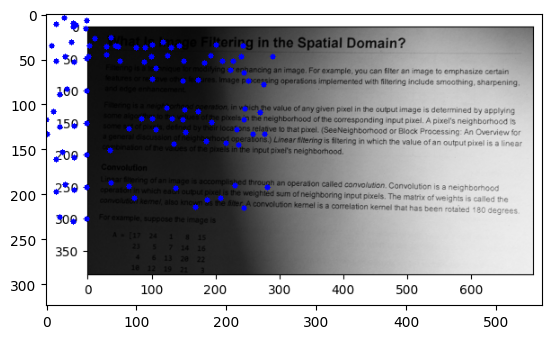

In [50]:
# 흑백 변환 >> 알고리즘 적용 >> 시각화
src = cv2.imread(image_path)
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

# 알고리즘 적용:goodFeaturesToTrack

# 추적하기 좋은 특징점
pts = cv2.goodFeaturesToTrack(
            gray,
            maxCorners=100,     # 최대 50개 특징점
            qualityLevel=0.01,  # 상위 1%만
            minDistance=10      # 특징점들끼리 최소 10px 떨어져 있어야 함
        )


if pts is not None:
  pts = pts.astype(np.uint8)
  for i in pts:
    x, y = i.ravel()  # ravel(): 1차원 배열로 펴줌
    cv2.circle(src, (x, y), 3, (0, 0, 255), -1)

plt.imshow(src)

허프 변환(Hough Transform)
- 직선 검출 가능
- 원 검출 가능

In [55]:
np.around(1.54) # np.float64(2.0) : 반올림
np.around(1.54).astype(np.int8) #np.int8(2)

np.int8(2)

In [56]:
# 이미지 읽어오기

image = cv2.imread('/content/drive/MyDrive/rokey/AI/application/3/water_coins.jpg')

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
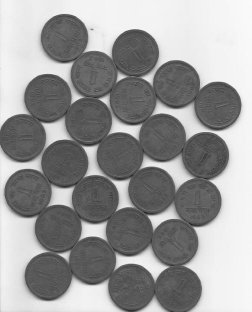

In [57]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

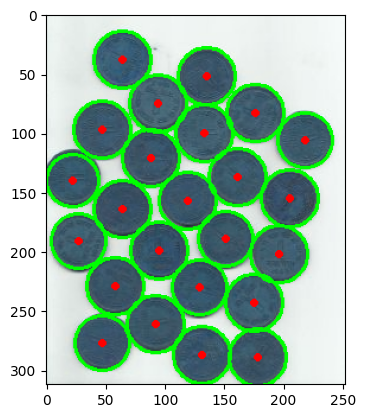

In [61]:
# 원 검출: 원(센터 x, y, 반지름) 목록이 담긴 배열
circles = cv2.HoughCircles( gray,                    # 이진화된 이미지
                            cv2.HOUGH_GRADIENT,      # 원 찾는 알고리즘 방식 (가장 많이 쓰는 방식)
                            dp=1.2,                  # 해상도 scale 비율(1.0 입력이미지와 같은 해상도)
                                                     # 해상도 줄이는 비율(1.2면 1/1.2로 줄여 빠르게 계산, 성능 떨어짐)
                            minDist=30,              # 검출된 원 사이 최소거리
                                                     # 원 중심간 간격이 30 이하 >> 중복 아니다(원 중심간 최소거리)
                            param1=100,              # 엣지(경계) 찾는 첫 번째 임계값(canny edge upper threshold)
                                                     # 값이 크면 → 윤곽 잘 잡지만 민감도 떨어짐, 값이 작으면 → 노이즈도 잡아서 원을 헷갈림
                            param2=40,               # 투표(voting)
                            minRadius=10,            # 찾고 싶은 원의 최소 반지름
                            maxRadius=50             # 찾고 싶은 원의최대 반지름
                            )

# 투표(voting) : 많은 점(pts)이 원을 지지하면 원으로 인정

# 원을 그리기 위해 픽셀 좌표/반지름을 정수화하는 과정
if circles is not None:
  circles = np.around(circles).astype(np.uint16)

  for (x,y,r) in circles[0, :]:
    # 원 그림에서 배열의 첫번째 차원(보통 1) 무시
    # 검출된 모든 원(n개) 정보만 선택
    # circles.shape: 3차원 배열 (1, N, 3) >> 무시하면 2차원 (N, 3) 취급 가능
    # 1 → 항상 1 (배치처럼 묶어서 줌. 의미 없음) / N → 검출된 원의 개수 / 3 → 각 원의 정보 (x좌표, y좌표, 반지름 r)
    # 여기서 검출된 첫번째 차원(1) 항상 크기가 1(배치가 1인것과 유사)
    cv2.circle(image, (x,y), r, (0,255,0), 2)
    cv2.circle(image, (x,y), 2, (255,0,0), 2) # 반지름 2 = 작은 점

  plt.imshow(image)


In [62]:
circles.shape

(1, 24, 3)

In [ ]:
# minDist=30,
# 검출된 원 사이 최소거리
# >> 원 중심간 간격이 30 이하 >> 중복 아니다
# >> 목적: 과잉 검출 방지
# 30 pixel 거리 이내 다른 원의 중심을 허용하지 않겠다
# 즉, 하나의 원에 대한 하나의 검출 결과만 보장한다
# 값이 작으면 서로 가까운 원들을 개별적인 원으로 검출 >> 비슷한 원 여러개가 생김
# 값이 크면 원이 너무 멀리 떨어진 경우에만 검출

# “원들끼리 최소한 30픽셀은 떨어져 있어야지, 같은 원을 두 번 찾지 않아!”
# 거리가 너무 작으면 하나의 원을 여러 개 찾는 문제가 생김.


# param2=40,     # 투표(voting) 누적 임계값(원으로 판단할 기준)
# 이 값이 작으면 → 원을 많이 찾음(가짜도 잡음)
# 이 값이 크면 → 확실한 원만 찾음(놓치는 원 많음)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
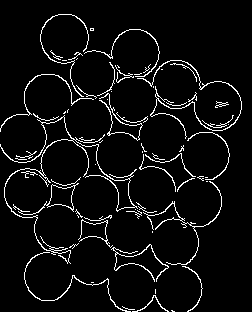

In [63]:
# 캐니 엣지 검출
edges = cv2.Canny(gray, 50, 150)
edges
# 엣지 있으면 255(흰색), 없으면 0(검정색)

ρ = x*cos (θ) + y*sin (θ)


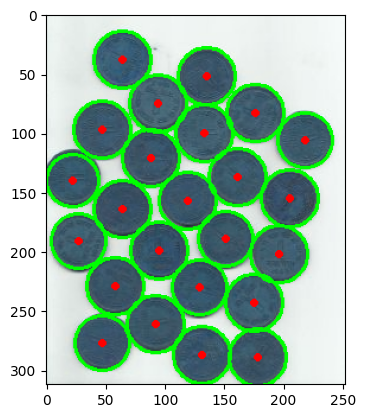

In [64]:
# 확률적 허프 직선 검출(HoughLinesP) - edge가 아닌 contour 윤곽선 검출
# >> 실제 길이 선분 형태로 반환(실무)
# cf. cv2.HoughLinesP 무한 직선 형태
# 곡선 ≈ 아주 많은 작은 직선들의 연결

lines = cv2.HoughLinesP(edges,            # 엣지(윤곽선) 이미지 (대부분 canny에서 만듦)
                        1,                # rho 해상도 : 거리 단위 해상도(몇 픽셀 간격으로 거리값을 살펴볼까? 1픽셀씩).
                        np.pi/180,        # theta 해상도(각도): np.pi/180 = 0°, 1°, 2°, … 180° 방향으로 직선이 있는지 1도씩 검사하겠다.
                        threshold=100,    # 직선이라고 인정할 최소 투표 수
                        minLineLength=10, # 내가 검출하려는 직선의 최소 길이
                        maxLineGap=10)    # 끊겨 있어도 이어서 직선 취급할 최대 간격
'''
lines 반환값:(1, 4) 형태의 배열들이 N개. / 직선 조각들을 반환
lines = [
    [[x1, y1, x2, y2]],
    [[x3, y3, x4, y4]],
    ...
]
'''
if lines is not None:
  for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(image, (x1,y1), (x2,y2), (0,0,255), 2)

plt.imshow(image)

# ρ(rho) : 원점(0,0)에서 직선까지의 거리 (1px 단위)
# θ(theta) : 각도 단위(radian) / np.pi/180 = 1도(degree)
# >> 각도 resolution이 크면, 직선 검출 정확도 떨어짐(상세하게 검사 안하니까)
# threshold=100, # 직선으로 간주될 수 있는 최소값(최소 투표수)
# >> 누적 투표수가 100 이상 되어야 선이라고 간주
# >> 높이면 확실한 직선만 검출 (노이즈 적어짐, 놓치는 게 많아짐), 낮추면 작은 선들도 다 검출
# minLineLength=10, # 내가 검출하려는 직선의 최소 길이 (길이가 10 px 미만 >> 무시)
# maxLineGap=10, # 직선으로 간주되는 간격(직선 간격 허용)
# >> 중간에 끊어져 있는 선이 있어요. 선들 간의 사이가 10 이하면 연결된 하나의 선으로 간주
